# Credit Card Fraud Detection – Notebook 03  
**PyTorch Autoencoder (Unsupervised Anomaly Detection)**

Goal:  
- Train an autoencoder **only on normal transactions**  
- Use reconstruction error (MSE) as anomaly score  
- Evaluate with PR-AUC and Precision-Recall curve  
- Compare to Isolation Forest baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import precision_recall_curve, auc, average_precision_score, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## Filter out normal transactioms to train the autoencoder on 

In [2]:
X_train_full = np.load('../data/processed/X_train.npy')
X_test       = np.load('../data/processed/X_test.npy')
y_train_full = np.load('../data/processed/y_train.npy')
y_test       = np.load('../data/processed/y_test.npy')

# For autoencoder: train ONLY on normal samples
normal_mask = y_train_full == 0
X_train_normal = X_train_full[normal_mask]

print(f"Normal training samples: {X_train_normal.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,} (fraud ratio: {y_test.mean():.4%})")

Normal training samples: 227,451
Test samples: 56,962 (fraud ratio: 0.1720%)


## Convert Numpy to Pytorch Tensors

In [3]:
# To float32 pytorch tensors
X_train_tensor = torch.from_numpy(X_train_normal).float()
X_test_tensor  = torch.from_numpy(X_test).float()

# DataLoader (batch training)
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(f"Number of batches per epoch: {len(train_loader)}")

Number of batches per epoch: 889


## Create Autoencoder model class

In [13]:
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        # Encoder (deeper: added 128 layer)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),          

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),          

            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),

            nn.Linear(16, 8)           
        )
        # Decoder 
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.LeakyReLU(0.2),

            nn.Linear(16, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),          

            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),           

            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = FraudAutoencoder().to(device)
print(model)

FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): LeakyReLU(negative_slope=0.2)
    (10): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=32, out_features=64, bias=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Linear(in_features=64, out_features=128, bias=Tr

## Training loop

Epoch [10/100]  Loss: 0.226205
Epoch [20/100]  Loss: 0.226482
Epoch [30/100]  Loss: 0.225342
Epoch [40/100]  Loss: 0.225891
Epoch [50/100]  Loss: 0.225550
Epoch [60/100]  Loss: 0.225902
Epoch [70/100]  Loss: 0.225039
Epoch [80/100]  Loss: 0.226006
Epoch [90/100]  Loss: 0.225163
Epoch [100/100]  Loss: 0.224780


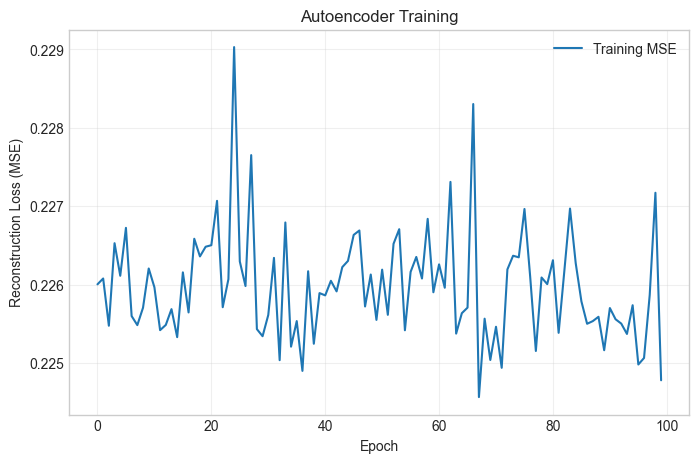

In [17]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, )


epochs = 100
train_losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        noise_factor = 0.05
        x_noisy = x + noise_factor * torch.randn_like(x)

        optimizer.zero_grad()
        recon = model(x_noisy)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
        scheduler.step(epoch_loss)

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == epochs-1:
        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.6f}")

# Plot training progress
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training MSE')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
model.eval()
with torch.no_grad():
    X_test_recon = model(X_test_tensor.to(device)).cpu().numpy()

test_errors = np.mean((X_test - X_test_recon)**2, axis=1)

normal_errors = test_errors[y_test == 0]
fraud_errors   = test_errors[y_test == 1]

print(f"Normal mean error:   {normal_errors.mean():.6f} ± {normal_errors.std():.6f}")
print(f"Fraud mean error:    {fraud_errors.mean():.6f} ± {fraud_errors.std():.6f}")
print(f"Separation ratio:    {fraud_errors.mean() / normal_errors.mean():.2f}x")

pr_auc = average_precision_score(y_test, test_errors)
print(f"PR-AUC: {pr_auc:.4f}")

Normal mean error:   0.153266 ± 0.591214
Fraud mean error:    18.556387 ± 21.328398
Separation ratio:    121.07x
PR-AUC: 0.6454


In [20]:
import os

# Create output directory if it doesn't exist
os.makedirs('../data/processed/scores', exist_ok=True)

# Autoencoder reconstruction errors (higher = more anomalous)
np.save('../data/processed/scores/autoencoder_recon_errors.npy', test_errors)
np.save('../data/processed/scores/autoencoder_y_test.npy', y_test)

print("Saved:")
print("  - ../data/processed/scores/autoencoder_recon_errors.npy")
print("  - ../data/processed/scores/autoencoder_y_test.npy")

Saved:
  - ../data/processed/scores/autoencoder_recon_errors.npy
  - ../data/processed/scores/autoencoder_y_test.npy


In [19]:
torch.save(model.state_dict(), '../models/autoencoder_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': 100,
    'loss': 0.22478,
}, '../models/autoencoder_checkpoint.pt')

## Final Autoencoder Results
- Final train MSE: ~0.225
- Normal test error: 0.153 ± 0.591
- Fraud test error: 18.56 ± 21.33
- Separation: **121×**
- PR-AUC: **0.6454** (strong unsupervised baseline)

→ Much better anomaly separation than Isolation Forest (PR-AUC 0.17)